# 02 -- The records: look before processing

This workbook builds the cache of every chosen site and looks at one of them, `SITE`. It draws that site's
record, its band coherence, its coherence maps, its spectra and its spectrograms. Nothing is processed here.
The five figures answer which channels the site recorded, over which days, and in which state: a reversed magnetic axis, a dead electric line, two lines carrying one noise, a gain, a turn of the
sensor, a rail or a step all show in them before any transfer function is estimated.

Only one site is looked at in a run, so the figures and the day tables below are `SITE`'s alone. The numbers
behind them are read at every chosen site, because the survey table at the end carries one row per site and
that table is what workbook 03 reads.

The cache is the record as laid. Every hourly file is placed on one absolute time axis by its own header
start and never concatenated, so a missing hour stays a gap and does not shift the hours after it; gaps are
NaN; the counts are converted to nT and mV/km by the instrument constants and the site's own dipole lengths.
No sign, no rotation and no notch is applied: the frame and the signs come from `decisions.csv` at processing
time, and a cache carrying them could not be re-read under a different decision.

Five checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported as FAIL and is
not revised afterwards.

This workbook writes two cells of `decisions.csv`. The DC test against IGRF decides `sign_hx` and `sign_hz`,
and with `WRITE_DECISIONS` True each is written into the site's row wherever that cell reads `decide`. A
cell holding a value or an `assume:` is never overwritten, and a sign the test could not read is left
`decide` and printed as open.

The words for the reference kinds are fixed in workbook 01 and used here as words: remote site, fleet stack,
observatory, stack + observatory, member.

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase1"  # any folder under surveys/; copy surveys/_template/ for your own survey
SITE = "Q53N"                 # the site whose five figures, DC test and electric-line table are drawn below
SITES = "all"                 # "all" | "largest" (the register's largest group) | a group name | ["Q49", "Q50"]
MAX_SITES = 0                 # 0 = every chosen site; a cap keeps an example short and names what it kept
WORK_ROOT = None              # None = survey.yaml work_root; every cache and figure lands under it
RATES = [1, 10]               # the caches built; 10 is EDL only, and a student short of disk sets [1]
WIN_MIN, STEP_MIN = 60, 30    # the base window and step of figures 02, 03 and 05, in minutes
PMAX = 20000                  # the longest period the level ladder reaches, in s
DEAD_FRACTION = 0.2           # a day of a line is dead below this fraction of the line's own median daily std
DEAD_ABS_MV_PER_KM = 0.0      # or below this absolute floor in mV/km; 0 = off (a line dead all record reads weak)
SIGN_FLOOR = 0.3              # a DC ratio against IGRF this far from zero is a sign; inside it, none is read
WRITE_DECISIONS = True        # True writes sign_hx and sign_hz into decisions.csv at every chosen site, into
                              # the cells that read `decide` and into no others. False leaves them `decide`,
                              # and a site whose magnetic signs stay `decide` is processed with them at +1:
                              # a reversed axis then reverses every transfer function row it enters
REBUILD = False               # True rebuilds every cache from the raw files, which is the slow path


## The survey and the chosen set

Everything below runs on `surveys/<SURVEY>/` and writes under that survey's `work_root`. `SITES` chooses the
set: `all` is every row of sites.csv, `largest` is the largest group of the deployment register workbook 01
wrote, a group name such as `G01` is that group, and a list is the sites it names. A group is the pool the
reference choices are drawn from, so running a workbook over one group is running it over a set of sites that
were recording at the same time.

`SITE` is the site the figures are drawn for. Where it is not in the chosen set it is added to it, so that its
cache is built with the group's.

In [2]:
import time
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timezone
from pathlib import Path

# mt_io logs one INFO line per file read, which is thousands of lines per site
from loguru import logger as _loguru
_loguru.disable("mt_io")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                   # the figures are written to disk and shown from there, not inline
import matplotlib.pyplot as plt
from IPython.display import Image, display

from auslamp_proc import survey as SV, look
from auslamp_proc.process import frame as FR
from auslamp_proc.raw import cache
from auslamp_proc.figures import record as FREC, site as FSITE

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 400)

sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])
CHOSEN, WHY = SV.select_sites(sv, SITES, MAX_SITES)
if SITE not in list(sv.sites.site):
    raise ValueError("SITE = %r is not a row of surveys/%s/sites.csv" % (SITE, SURVEY))
if SITE not in CHOSEN:                  # <- SITE is drawn below, so its cache is built with the group's
    CHOSEN = [SITE] + CHOSEN
    WHY += "; with %s, the site the figures are drawn for" % SITE
WRITTEN = []
TIMING = {}

def site_dir(s):
    d = WORK / s
    d.mkdir(parents=True, exist_ok=True)
    return d

def load(s):
    """The site's 1 Hz cache and its row. One site is held at a time: a 60 d record is 105 MB a channel."""
    t0, arrays, meta = cache.load(s, WORK, 1)
    return t0, arrays, meta, sv.site(s)

def midpoint(t0, n, fs=1.0):
    return datetime.fromtimestamp(t0 + n / fs / 2, timezone.utc)

def show(name):
    """Draw one of SITE's figures from the file it was written to."""
    p = WORK / SITE / name
    if p.exists():
        display(Image(filename=str(p)))

print("survey       %s" % sv.cfg["name"])
print("work root    %s" % WORK)
print("sites        %d chosen from %s" % (len(CHOSEN), WHY))
print("             %s" % " ".join(CHOSEN))
print("rates        %s Hz" % ", ".join(str(r) for r in RATES))
print("windows      %d min every %d min, periods 2 .. %g s" % (WIN_MIN, STEP_MIN, PMAX))
print("site         %s; its five figures, its DC test and its electric-line table are drawn below" % SITE)


survey       queensland_phase1
work root    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1
sites        23 chosen from every site in sites.csv
             Q49 Q50 Q51 Q52N Q53N Q60N Q61N Q62N Q63 Q64N Q65 Q72N Q73 Q74N Q75 Q76ALT Q77N Q83 Q84 Q85N Q86N Q87 Q88N
rates        1, 10 Hz
windows      60 min every 30 min, periods 2 .. 20000 s
site         Q53N; its five figures, its DC test and its electric-line table are drawn below


## The sites

The chosen set, with the dipole lengths the electric channels are divided by and the source of each. A cell
reading `assume:<value>` is used and carried into the provenance of every transfer function the site delivers
until a sheet replaces it, and is named as an assumption below. The dipoles matter to the level of every
apparent resistivity the survey will produce: rho scales with the square of the dipole length, so a dipole
wrong by 20 per cent moves rho by 44 per cent.

In [3]:
rows = []
for s in CHOSEN:
    r = sv.site(s)
    dn, kn = cache.dipole_value(r.dipole_n_m)
    de, ke = cache.dipole_value(r.dipole_e_m)
    rows.append(dict(site=s, instrument=r.instrument, sample_rate_hz=r.sample_rate_hz,
                     days=r.days, dipole_n_m=dn, dipole_e_m=de,
                     assumed=" ".join([k for k, v in (("Ex", kn), ("Ey", ke)) if v == "assume"]) or "",
                     dipole_source=str(r.dipole_source)[:70]))
chosen_table = pd.DataFrame(rows)
print(chosen_table.to_string(index=False))
print()
n_assumed = int((chosen_table.assumed != "").sum())
print("%d of %d sites carry an assumed dipole (%s)"
      % (n_assumed, len(chosen_table), ", ".join(chosen_table.site[chosen_table.assumed != ""]) or "none"))
print()
print("the instrument constants the counts are converted by, from survey.yaml")
for inst, k in (sv.cfg.get("instruments") or {}).items():
    print("%s" % inst)
    for key, val in k.items():
        print("   %-14s %s" % (key, val))


  site    instrument sample_rate_hz   days  dipole_n_m  dipole_e_m assumed                                              dipole_source
   Q49 PR6-24+Mag-03           10.0 60.637       10.20        11.2           deployment sheet transcribed 2026-09-05, confidence high
   Q50 PR6-24+Mag-03           10.0 61.402       10.50        12.2           deployment sheet transcribed 2026-09-05, confidence high
   Q51 PR6-24+Mag-03           10.0 61.027        9.00         9.5           deployment sheet transcribed 2026-09-05, confidence high
  Q52N PR6-24+Mag-03           10.0 61.767        9.00         9.5         deployment sheet transcribed 2026-09-05, confidence medium
  Q53N PR6-24+Mag-03           10.0 61.035       10.10        10.0           deployment sheet transcribed 2026-09-05, confidence high
  Q60N PR6-24+Mag-03           10.0  60.82       11.00        10.0           deployment sheet transcribed 2026-09-05, confidence high
  Q61N PR6-24+Mag-03           10.0 60.581        9.00        

## The cache

Each site is built once and then read from disk. The reconciliation below is the placement's own arithmetic:
every file found on disk, every file read, every sample read, every sample written onto the axis, and every
sample written over a value already there. An hour the recorder wrote twice raises `overlap_samples`; an hour
it could not write leaves NaN and lowers nothing, which is why the NaN fraction is a separate column and not
part of the equality. This section is a table of what was built, at every chosen site; no figure is drawn
from it.

**This check fails if, at any site, samples placed differs from samples read, or any two files overlap, or a
channel is more than 50 per cent NaN, or the rate read differs from the rate survey.yaml gives the
instrument.**

In [4]:
recon, prov_all, built = [], {}, []
want_rate = {i: float(b["sample_rate_hz"]) for i, b in sv.cfg["instruments_layout"].items()}
for s in CHOSEN:
    t = time.time()
    row = sv.site(s)
    prov = cache.build(row, sv.cfg, rates=tuple(RATES), force=REBUILD)   # <- REBUILD True re-reads the raw
    TIMING[s] = {"cache_s": round(time.time() - t, 1)}
    prov_all[s] = prov
    built.append("%-9s %6.1f s  %7.3f d  %s" % (s, TIMING[s]["cache_s"], prov["span_days"],
                                                prov["verdict_lines"][-1]))
    recon += cache.reconciliation_row(prov)
    print(built[-1], flush=True)

recon = pd.DataFrame(recon)
print()
print(recon.to_string(index=False))

span = pd.DataFrame([dict(site=s, t0=prov_all[s]["t0_iso"][:16], span_days=prov_all[s]["span_days"],
                          fs_raw=prov_all[s]["fs_raw"], n_1hz=prov_all[s]["n_1hz"],
                          worst_nan=max(prov_all[s]["nan_fraction_1hz"].values()))
                     for s in CHOSEN])
print()
print(span.to_string(index=False))

mismatch = recon[(recon.samples_placed != recon.samples_read) | (recon.overlap_samples > 0)
                 | (recon.files_read != recon.files_found) | (recon.files_unplaced > 0)]
nanny = recon[recon.nan_fraction > 0.5]
rate_bad = [(s, prov_all[s]["fs_raw"], want_rate.get(sv.site(s).instrument))
            for s in CHOSEN if abs(prov_all[s]["fs_raw"] - want_rate.get(sv.site(s).instrument, -1)) > 1e-6]
print()
if not len(recon):
    print("VERDICT: UNJUDGED -- no site was built, so no channel was reconciled")
elif len(mismatch) or len(nanny) or rate_bad:
    print("VERDICT: FAIL -- %d of %d channel rows do not place every sample they read without overlap (%s); "
          "%d channels are more than 50 %% NaN (%s); %d sites read a rate that is not survey.yaml's (%s)"
          % (len(mismatch), len(recon),
             "; ".join("%s %s placed %d of %d, overlap %d" % (r.site, r.channel, r.samples_placed,
                                                              r.samples_read, r.overlap_samples)
                       for r in mismatch.itertuples()) or "none",
             len(nanny), "; ".join("%s %s %.0f %%" % (r.site, r.channel, 100 * r.nan_fraction)
                                   for r in nanny.itertuples()) or "none",
             len(rate_bad), "; ".join("%s %g vs %g Hz" % x for x in rate_bad) or "none"))
else:
    print("VERDICT: PASS -- %d sites, %d channel rows: every sample read was placed (%d in all), no two files "
          "overlap, the worst channel is %.1f %% NaN at %s, and every site reads %s"
          % (len(CHOSEN), len(recon), int(recon.samples_placed.sum()), 100 * recon.nan_fraction.max(),
             recon.site[recon.nan_fraction.idxmax()],
             ", ".join("%g Hz" % v for v in sorted(set(want_rate.values())))))


Q49          0.0 s   60.637 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q50          0.0 s   61.402 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q51          0.0 s   61.027 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q52N         0.0 s   61.767 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q53N         0.0 s   61.035 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


...

Q85N         0.0 s   60.681 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q86N         0.0 s   12.076 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q87          0.0 s   60.748 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q88N         0.0 s   60.453 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap



  site channel  files_found  files_read  samples_read  samples_placed  overlap_samples  files_unplaced  nan_fraction
   Q49      Hx         1455        1455      52354200        52354200                0               0        0.0007
   Q49      Hy         1456        1456      52390200        52390200                0               0        0.0000
   Q49      Hz         1456        1456      52390200        52390200                0               0        0.0000
   Q49      Ex         1456        1456      52390200        52390200                0               0        0.0000
   Q49      Ey         1456        1456      52390200        52390200                0               0        0.0000
   Q50      Hx         1474        1474      53051400        53051400                0               0        0.0000
   Q50      Hy         1474        1474      53051400        53051400                0               0        0.0000
   Q50      Hz         1474        1474      53051400        53

## The record (figure 01) and the DC field

Figure 01 is `SITE`'s whole 1 Hz record as laid, in eight panels: the five channels as a per-minute mean drawn
over the per-minute range, then H = sqrt(Hx^2 + Hy^2), F = sqrt(Hx^2 + Hy^2 + Hz^2), and the hourly sensor
angle atan2(Hy, Hx). Each magnetic panel carries the IGRF value at the site at the record midpoint and the
ratio of the measured median to it.

What to look for, in this order:

- a reversed axis: Bx below zero, or a panel that is the mirror of its neighbours';
- a dead channel: a flat line, or a range of a few counts where the others move tens of nT;
- a gain: F away from IGRF by more than 5 per cent, with H and Z away by the same factor;
- a turn of the sensor: a step in the hourly angle, which is the mast being knocked or re-laid, and splits the
  record into rotation regimes;
- a rail: a channel pinned at a constant for hours, which is the amplifier at its limit;
- a step: a jump in an electric line, which is an electrode being disturbed.

The table under the figure is the DC test of `SITE`: the medians against IGRF, the three ratios, the sensor
angle, the tilt and the flags. The same test is run at every chosen site, each site's row is written to
`<work_root>/<site>/dc.csv`, and its columns are in the survey table at the end. The rules, in the order they
fire, are `|F/F_igrf - 1| > 0.05` a gain or a broken axis; else `|Bz/Z - 1| > 0.10` or `|H/H_igrf - 1| > 0.10`
a tilt; `Bx < 0` a reversed north axis; `|angle| > 30 deg` a sensor laid far from north or the axes exchanged
(`auslamp_proc.look.dc_test`).

The check tests that the rule fires where the numbers say it must, at every chosen site.

**This check fails if any site's F differs from IGRF by more than 5 per cent without a flag naming it, or if
any Bx is negative without a flag.**

Q53N        2.2 s  Q53N: 61.0 d; median Hx 29736 Hy -134 Hz -41444 nT, H 29736 F 51007 nT, Ex 33.25 Ey 806.29 mV/km, angle -0.3 deg

the DC test of Q53N
site  days      Bx     By       Bz       H       F  igrf_X  igrf_Y   igrf_Z  igrf_H  igrf_F  Bx_over_X  Bz_over_Z  H_over_Higrf  F_over_Figrf  angle_deg  tilt_deg flags verdict
Q53N 61.03 29735.9 -134.3 -41443.8 29736.2 51008.2 29199.9  5174.6 -42404.5 29654.9 51745.1     1.0184     0.9773        1.0027        0.9858      -0.26      0.69          PASS


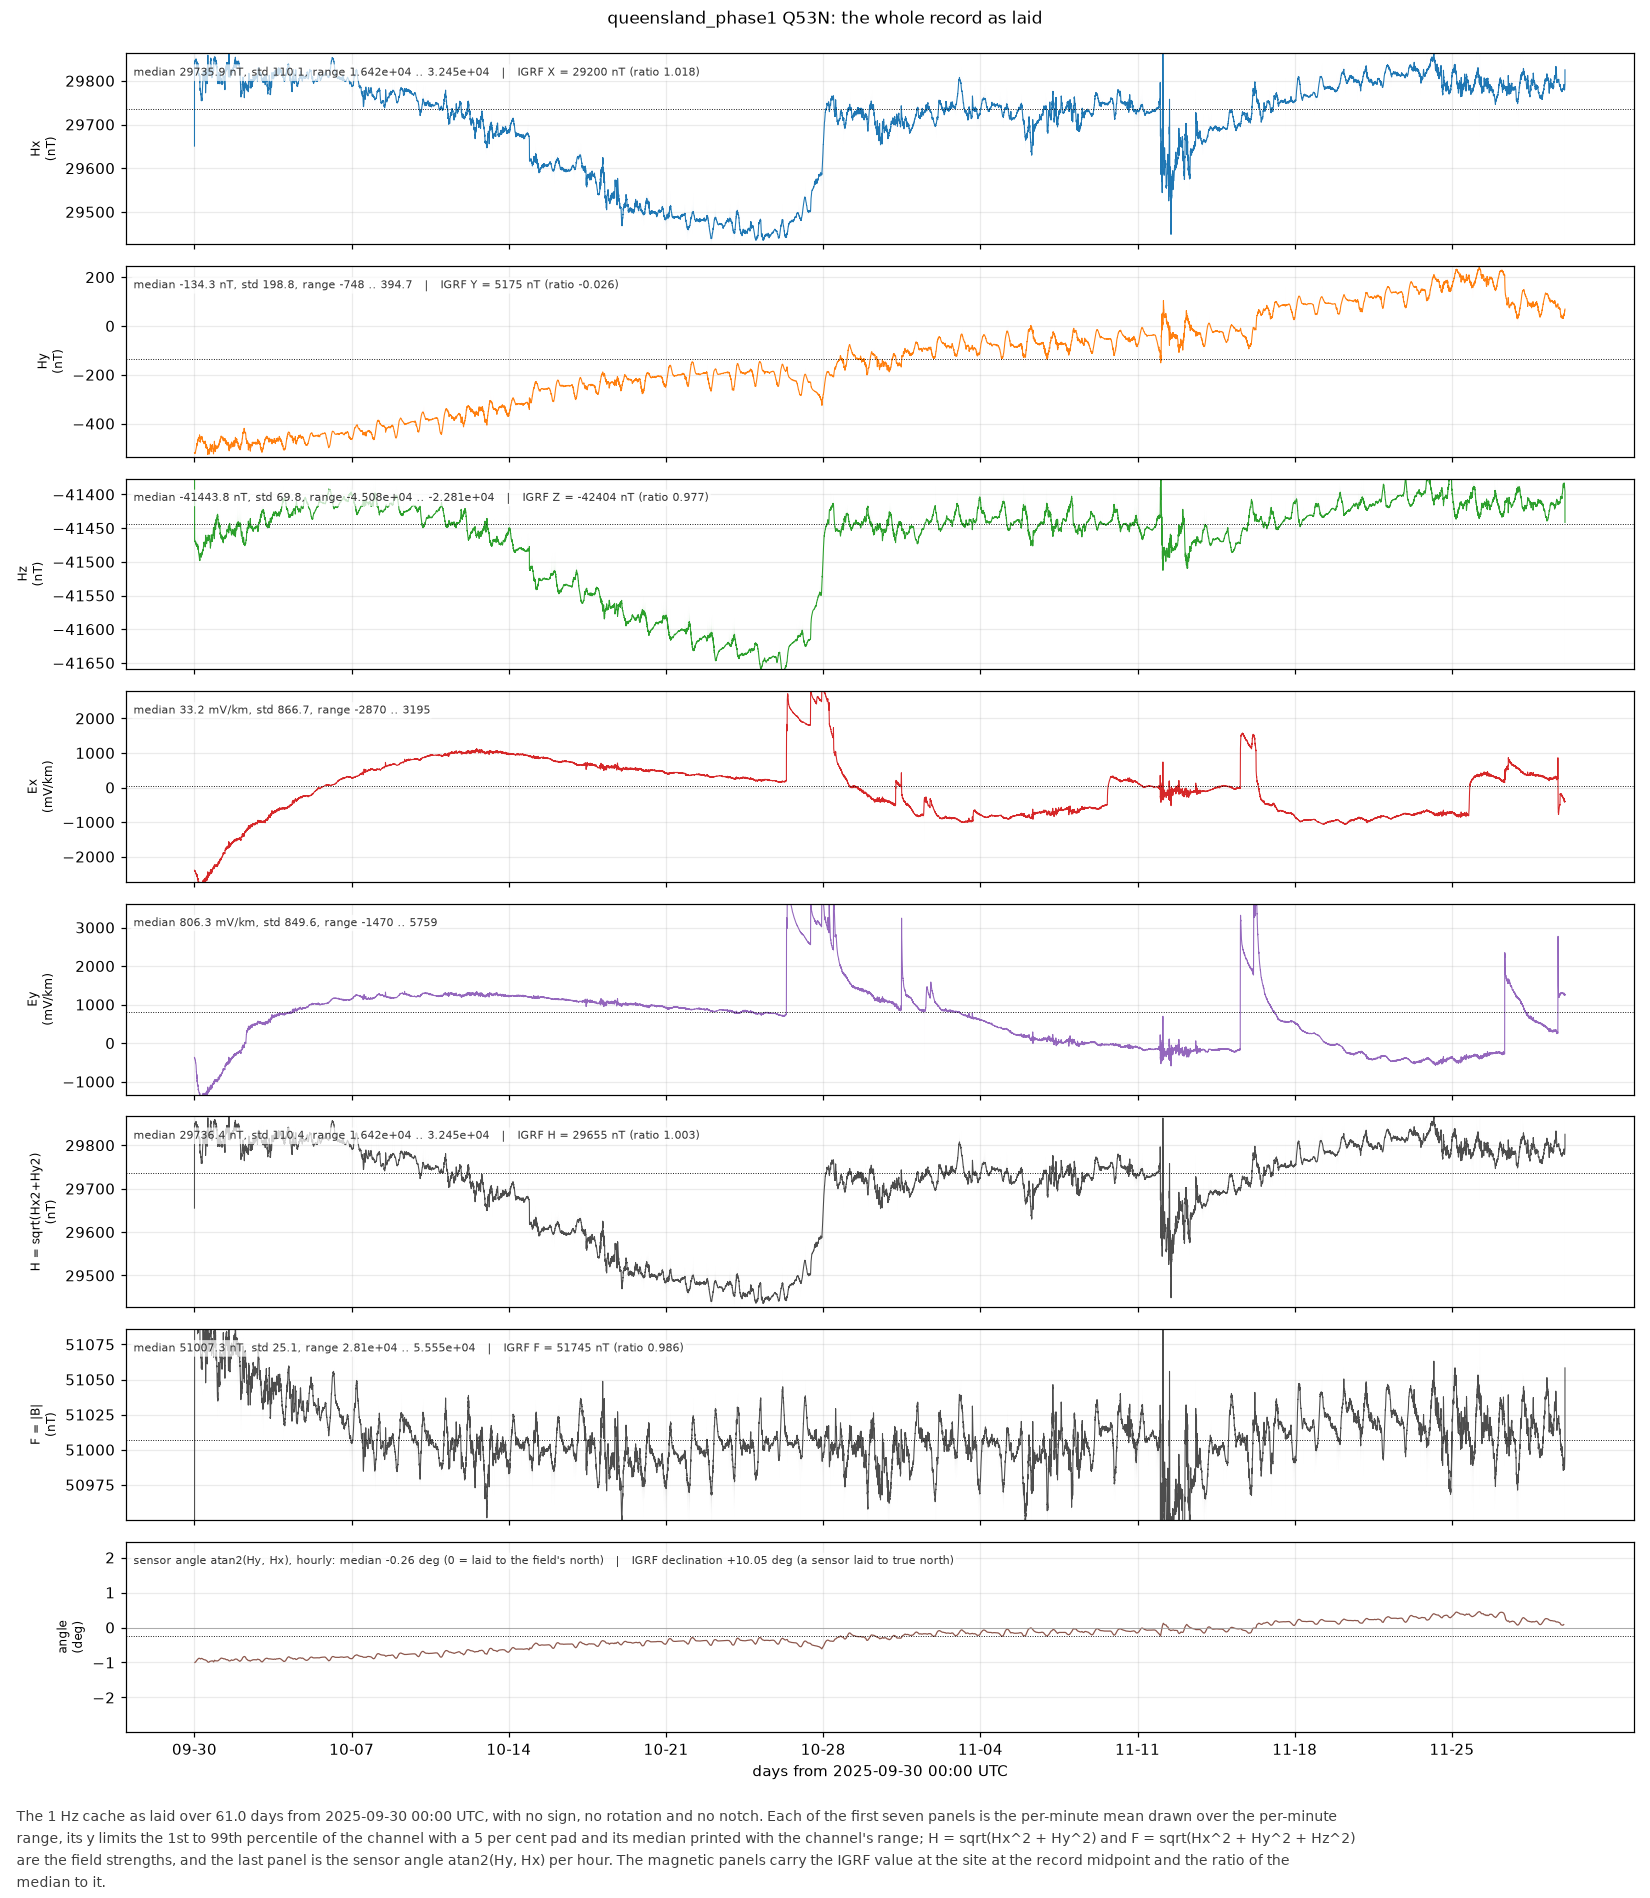


1 of 23 sites carry a flag: Q65 [F/Figrf 1.16 (gain or a broken axis); Bx negative; angle -180 deg]

VERDICT: PASS -- all 23 sites scored; the 1 sites over 5 % in F (Q65) and the 1 with Bx below zero (Q65) each carry the flag the rule fires, and the largest F/F_igrf departure is 16.3 % at Q65


In [5]:
dc_rows = []
for s in CHOSEN:
    t = time.time()
    t0, arrays, meta, row = load(s)
    n = len(arrays["Hx"])
    d = look.dc_test(arrays, float(row.lat), float(row.lon), float(row.elev_m), midpoint(t0, n))
    d["site"] = s
    d["days"] = round(n / 86400.0, 2)
    dc_rows.append(d)
    pd.DataFrame([d]).to_csv(site_dir(s) / "dc.csv", index=False)
    WRITTEN.append(site_dir(s) / "dc.csv")
    if s == SITE:                                   # <- SITE: figure 01 is drawn for the one site
        fig, line = FREC.record(t0, arrays, site_dir(s) / "01_record.png", site=s, survey=sv.cfg["name"],
                                lat=float(row.lat), lon=float(row.lon), elev_m=float(row.elev_m), fs=1.0)
        plt.close(fig)
        WRITTEN.append(site_dir(s) / "01_record.png")
    TIMING[s]["record_s"] = round(time.time() - t, 1)
    del arrays

dc = pd.DataFrame(dc_rows)[["site", "days", "Bx", "By", "Bz", "H", "F", "igrf_X", "igrf_Y", "igrf_Z",
                            "igrf_H", "igrf_F", "Bx_over_X", "Bz_over_Z", "H_over_Higrf", "F_over_Figrf",
                            "angle_deg", "tilt_deg", "flags", "verdict"]]
print("%-9s %5.1f s  %s" % (SITE, TIMING[SITE]["record_s"], line))
print()
print("the DC test of %s" % SITE)
print(dc[dc.site == SITE].to_string(index=False))
show("01_record.png")

f_off = dc[(dc.F_over_Figrf - 1).abs() > 0.05]
# dc["flags"], not dc.flags: a DataFrame already carries a `flags` attribute of its own
f_unflagged = f_off[~f_off["flags"].str.contains("F/Figrf", na=False)]
bx_neg = dc[dc.Bx < 0]
bx_unflagged = bx_neg[~bx_neg["flags"].str.contains("Bx negative", na=False)]
print()
print("%d of %d sites carry a flag: %s"
      % (int((dc["flags"] != "").sum()), len(dc),
         "; ".join("%s [%s]" % (r.site, r.flags) for r in dc.itertuples() if r.flags) or "none"))
print()
if not len(dc):
    print("VERDICT: UNJUDGED -- no site was read, so no DC field was scored")
elif len(f_unflagged) or len(bx_unflagged):
    print("VERDICT: FAIL -- %d of %d sites are more than 5 %% off IGRF in F with no flag naming it (%s); "
          "%d sites have Bx below zero with no flag (%s)"
          % (len(f_unflagged), len(dc), ", ".join(f_unflagged.site) or "none",
             len(bx_unflagged), ", ".join(bx_unflagged.site) or "none"))
else:
    print("VERDICT: PASS -- all %d sites scored; the %d sites over 5 %% in F (%s) and the %d with Bx below "
          "zero (%s) each carry the flag the rule fires, and the largest F/F_igrf departure is %.1f %% at %s"
          % (len(dc), len(f_off), ", ".join(f_off.site) or "none", len(bx_neg),
             ", ".join(bx_neg.site) or "none", 100 * (dc.F_over_Figrf - 1).abs().max(),
             dc.site[(dc.F_over_Figrf - 1).abs().idxmax()]))


### The two magnetic signs this test decides

`sign_hx` and `sign_hz` are read off the same numbers. An axis laid the right way up reads the IGRF
component it points at, so the sign of the record median over IGRF is the sign of the channel: `Bx/X` for
the north axis, `Bz/Z` for the vertical. Inside the floor `SIGN_FLOOR` = 0.3 the ratio says nothing, because
a dead coil sits near zero and so does a sensor laid at right angles to north, and the cell stays `decide`
rather than taking a sign off noise (`auslamp_proc.look.signs_from_dc`).

Two conditions stop the rule before the floor is reached, and each leaves the cell `decide` with its reason
printed:

- the DC test fired a flag other than `Bx negative` -- a gain, a broken axis, a tilt, a sensor laid far from
  north. The ratio is then not the component the axis is supposed to carry, so a polarity read off it is a
  polarity read off the wrong number;
- `decisions.csv` gives the site an `h_lender` covering that channel. The pass reads the lender's H there,
  so the site's own polarity never reaches a transfer function and recording it would record a decision
  nothing uses.

`sign_hy` is not decided here and no workbook decides it. The east component of the field is small, so `By/Y`
is near zero at an Australian site whatever the coil did; Hy is decided against the observatory's east
channel and two neighbours, which is a different measurement, and until somebody makes it the cell reads
`decide` and Hy is used as +1.

With `WRITE_DECISIONS` True each sign the rule decided is written into `surveys/<SURVEY>/decisions.csv` at
every chosen site, into a cell that reads `decide` and into no other: a cell already holding a value or an
`assume:` belongs to whoever put it there, and this test is a reading beside it and not a ruling over it
(`auslamp_proc.survey.write_signs` and `write_table`). `sign_source` gains one clause per sign, naming the
column, the value, the ratio it was read from and the date.

**This check fails if a cell this cell wrote did not read `decide` before the write, if a sign the rule
decided and `WRITE_DECISIONS` asked for is still `decide` afterwards, or if a cell now holds a value other
than the one the rule measured.** All three limbs are scored by reading `decisions.csv` back off the disk
and comparing it with the table as it stood before the write, which is an observable independent of the
call that wrote it. With `WRITE_DECISIONS` False nothing is asked for and nothing is scored, and the cell
reports UNJUDGED rather than passing on nothing.

In [6]:
BEFORE = SV.load_survey(SURVEY).decisions.set_index("site")
SIGN_COLS = [FR.SIGN_COLUMN["Hx"], FR.SIGN_COLUMN["Hz"]]
MEASURED, sign_rows = {}, []
for r in dc.to_dict("records"):
    got = look.signs_from_dc(r, floor=SIGN_FLOOR)       # <- SIGN_FLOOR
    # a channel decisions.csv replaces with a lender's never reaches a transfer function under its own
    # sign, so its polarity is not a measurement worth recording and the cell is left as it stands
    d_row = sv.decision(r["site"]) if r["site"] in list(sv.decisions.site) else None
    lender = FR.read_lender(d_row) if d_row is not None else ""
    borrowed = FR.read_lender_channels(d_row) if d_row is not None else []
    for ch in list(got):
        if lender and ch in borrowed:
            got[ch] = (None, "decisions.csv gives %s the H of %s, so this site's own %s never reaches a "
                             "transfer function" % (r["site"], lender, ch))
    MEASURED[r["site"]] = {FR.SIGN_COLUMN[ch]: (v, "the DC test of workbook 02: %s" % why)
                           for ch, (v, why) in got.items()}
    held = {c: (str(BEFORE.loc[r["site"], c]) if r["site"] in BEFORE.index else "") for c in SIGN_COLS}
    sign_rows.append(dict(site=r["site"], Bx_over_X=r["Bx_over_X"], Bz_over_Z=r["Bz_over_Z"],
                          rule_hx=got["Hx"][0], rule_hz=got["Hz"][0],
                          held_hx=held[SIGN_COLS[0]], held_hz=held[SIGN_COLS[1]],
                          why=("; ".join(w for v, w in got.values() if v is None))[:90]))
signs = pd.DataFrame(sign_rows)
print("the two ratios, the sign the %.1f floor reads from each, and what decisions.csv held before this run"
      % SIGN_FLOOR)
print(signs.to_string(index=False))

if not WRITE_DECISIONS:
    line, written = "WRITE_DECISIONS is False, so decisions.csv was not opened", []
    print()
    print(line)
else:
    line, written = SV.write_signs(sv.folder, MEASURED)
    print()
    print(line)
    for w in written:
        print("   wrote %s" % w)
    if not written:
        print("   no cell to write: every sign the rule decided is already decided in the file")

AFTER = SV.load_survey(SURVEY).decisions.set_index("site")
open_now, over_written, wrong_value, not_written = [], [], [], []
for s in CHOSEN:
    if s not in AFTER.index:
        continue
    for ch, col in (("Hx", SIGN_COLS[0]), ("Hz", SIGN_COLS[1])):
        was = str(BEFORE.loc[s, col]).strip() if s in BEFORE.index else ""
        now = str(AFTER.loc[s, col]).strip()
        rule = MEASURED[s][col][0] if s in MEASURED else None
        if now.lower() == "decide":
            open_now.append("%s %s: %s" % (s, col, MEASURED[s][col][1] if s in MEASURED else "not measured"))
            if WRITE_DECISIONS and rule is not None:
                not_written.append("%s %s" % (s, col))
        elif was != now:
            if was.lower() != "decide":
                over_written.append("%s %s: %s -> %s" % (s, col, was, now))
            elif rule is None or now != "%+d" % int(rule):
                wrong_value.append("%s %s: holds %s, the rule read %s" % (s, col, now, rule))
print()
print("still open after this cell, with the reason each was not decided:")
for lnn in open_now[:20]:
    print("   %s" % lnn)
if not open_now:
    print("   none: every chosen site carries a decided sign_hx and sign_hz")

print()
if not WRITE_DECISIONS:
    print("VERDICT: UNJUDGED -- WRITE_DECISIONS is False, so no cell was asked for and none was written; "
          "the %d sign(s) the rule decided are the reading above and decisions.csv is untouched"
          % sum(1 for s in MEASURED for v, _w in MEASURED[s].values() if v is not None))
elif over_written or wrong_value or not_written:
    print("VERDICT: FAIL -- %d cell(s) that did not read decide were overwritten (%s); %d hold a value the "
          "rule did not measure (%s); %d the rule decided are still decide (%s)"
          % (len(over_written), "; ".join(over_written[:6]) or "none",
             len(wrong_value), "; ".join(wrong_value[:6]) or "none",
             len(not_written), ", ".join(not_written[:8]) or "none"))
else:
    print("VERDICT: PASS -- %d sign cell(s) were written over %d chosen site(s), every one of them a cell "
          "that read decide, every one now holding the value the rule measured, and the %d cell(s) the rule "
          "could not decide are still decide and named above"
          % (len(written), len(CHOSEN), len(open_now)))


the two ratios, the sign the 0.3 floor reads from each, and what decisions.csv held before this run
  site  Bx_over_X  Bz_over_Z  rule_hx  rule_hz held_hx held_hz                                                                                        why
   Q49     0.9681     0.9846      NaN      NaN      +1      +1 decisions.csv gives Q49 the H of Q50, so this site's own Hx never reaches a transfer funct
   Q50     0.9861     1.0059      1.0      1.0      +1      +1                                                                                           
   Q51     0.9886     1.0114      1.0      1.0      +1      +1                                                                                           
  Q52N     0.9981     0.9911      1.0      1.0      +1      +1                                                                                           
  Q53N     1.0184     0.9773      1.0      1.0      +1      +1                                                                    

## Band coherence (figure 02) and the electric lines

Figure 02 is `SITE`'s squared coherence of four pairs against time, one line per band (5-20, 20-200, 100-1000
and 1000-10000 s) on a 12 h running median. How to read them:

| pair | what it is |
|---|---|
| Bx-Ey and By-Ex | the impedance pairs: this is the coherence the transfer function is estimated from |
| Bx-By | the polarisation of the source: a stretch where it rises to one is a single-polarisation event, and a tensor cannot be resolved there |
| Ex-Ey | the two electric lines against each other: high with Bx-By low is common-mode electric noise, the shared electrode of the L array carrying one signal into both lines |

The table under it is `SITE`'s per-UTC-day state of each line: the 20-200 s coherence of Ex with the site's own
Hy and of Ey with its Hx, of Ex with Ey, and the standard deviation of each line after a 3,000 s high-pass,
with the state `dead` (high-passed std under `DEAD_FRACTION` = 0.2 of the line's own median daily std, or under
the absolute floor `DEAD_ABS_MV_PER_KM` where one is set; the threshold is relative because the level of a
line scales with its dipole length and differs between surveys), `sound` (coherence with H at least 0.4 and
Ex-Ey under 0.5), `common` (Ex-Ey at least 0.6 and coherence with H under 0.3) or `weak`
(`auslamp_proc.look.elines`). A line dead for its whole record sits at its own noise floor and reads `weak`
under the relative rule; the absolute floor is the switch for that case.
Every series is despiked before the high-pass: one logger spike inside one Welch segment otherwise puts a
whole day's coherence at zero. A day in which any of the four channels is under 80 per cent finite is scored
`gap` and is not a scored day.

The same day table is built at every chosen site and written to `<work_root>/<site>/elines.csv`; the fraction
of scored days each line was sound, common-mode, dead or weak is in the survey table at the end, and the check
below is scored over every chosen site.

Figure 03's coherence maps are computed in the same pass and written with figure 02, because the band lines
are the same numbers averaged over a band.

**This check fails if the state machine is UNJUDGED at any site, that is if no day was scored.**

Q53N       83.1 s  days  61 scored  61 | Ex sound 0.00 common 0.13 dead 0.00 | Ey sound 0.00 common 0.10 dead 0.00

the day table of Q53N; every chosen site's own table is in its elines.csv
       day    t_start      t_end  coh_Ex_Hy  coh_Ey_Hx  coh_Ex_Ey  std_Ex  std_Ey  dead_std_Ex  dead_std_Ey Ex_state Ey_state gap_reason
2025-09-30 1759190400 1759276800      0.535      0.569      0.950  14.108  13.654       1.4276       1.3546     weak     weak           
2025-10-01 1759276800 1759363200      0.516      0.589      0.967  10.658  10.275       1.4276       1.3546     weak     weak           
2025-10-02 1759363200 1759449600      0.538      0.581      0.973   9.944   9.540       1.4276       1.3546     weak     weak           
2025-10-03 1759449600 1759536000      0.465      0.627      0.973   8.497   8.104       1.4276       1.3546     weak     weak           
2025-10-04 1759536000 1759622400      0.414      0.640      0.960   5.972   5.730       1.4276       1.3546     weak     weak

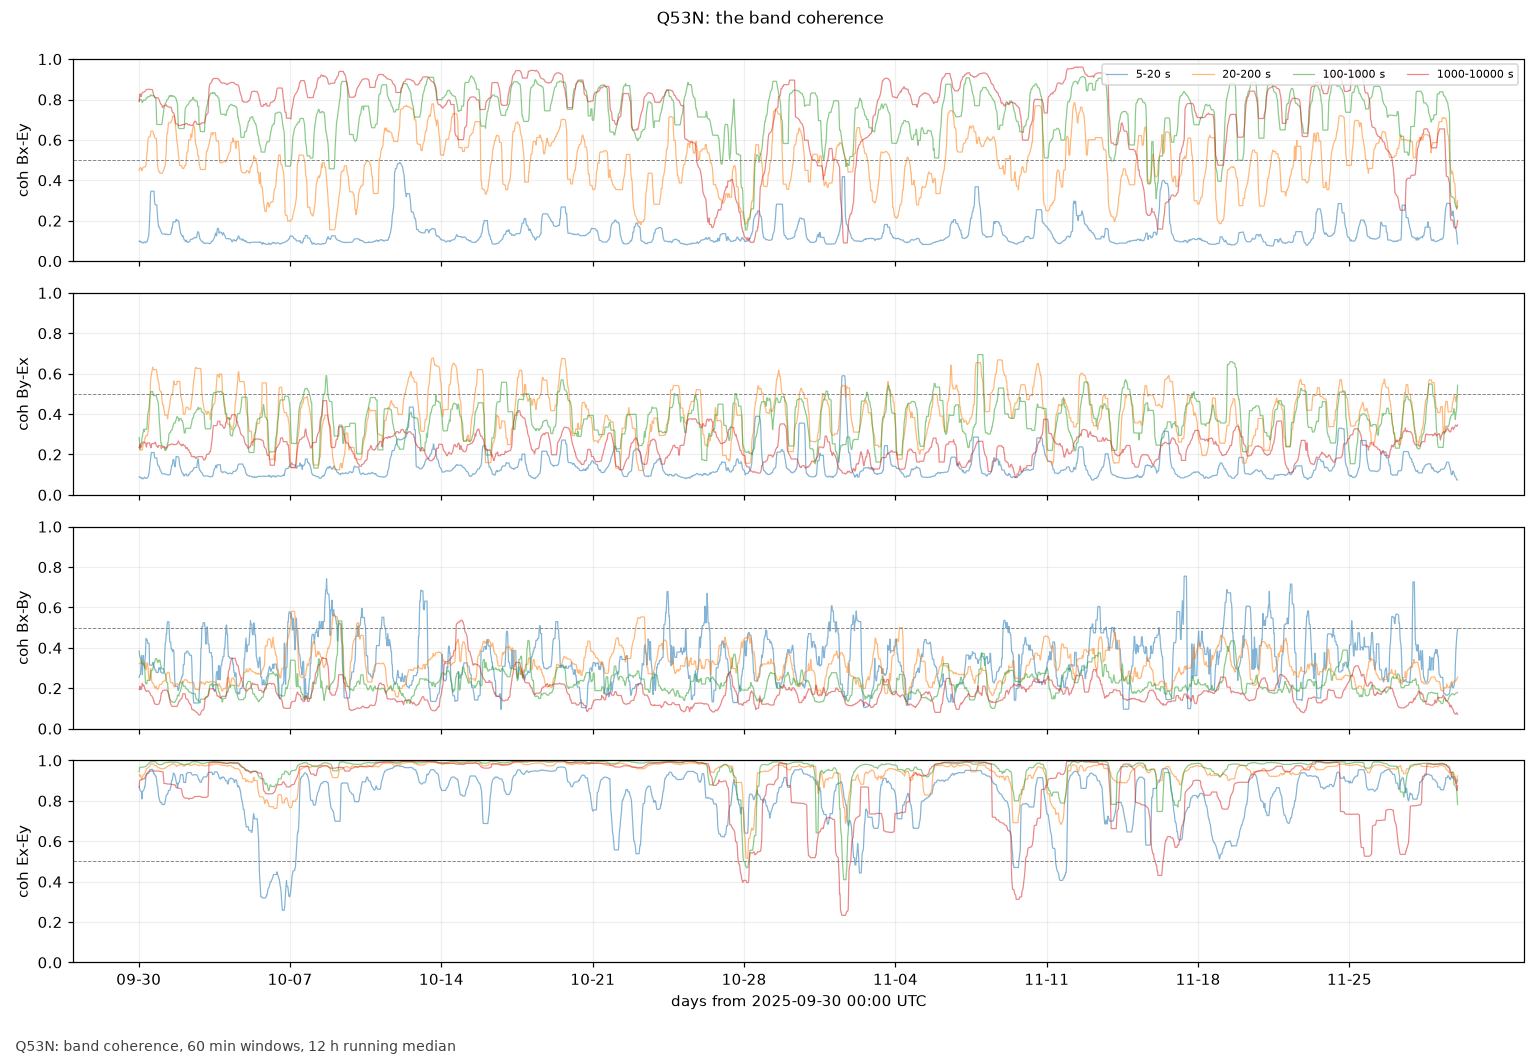


VERDICT: FAIL -- the state machine scored no day at 1 of 23 sites (Q87, refused on Ex:18 Ey:18 Hx:60 Hy:61)


In [7]:
e_rows = []
for s in CHOSEN:
    t = time.time()
    t0, arrays, meta, row = load(s)
    el = look.elines(t0, arrays, fs=1.0, dead_fraction=DEAD_FRACTION,        # <- DEAD_FRACTION, DEAD_ABS_MV_PER_KM
                     dead_abs_mv_per_km=DEAD_ABS_MV_PER_KM)
    el.to_csv(site_dir(s) / "elines.csv", index=False)
    WRITTEN.append(site_dir(s) / "elines.csv")
    e_rows.append(look.eline_summary(el, s))
    if s == SITE:                             # <- SITE: figures 02 and 03 are drawn for the one site
        day_table = el
        fig, maps = FSITE.coherence_maps(
            t0, arrays, site_dir(s) / "03_coherence_maps.png", fs=1.0,
            win_s=WIN_MIN * 60, step_s=STEP_MIN * 60, pmax=PMAX,          # <- WIN_MIN, STEP_MIN, PMAX
            title="%s: squared coherence, %d min windows every %d min" % (s, WIN_MIN, STEP_MIN))
        plt.close(fig)
        fig = FSITE.coherence_bands(t0, maps, site_dir(s) / "02_coherence_bands.png", len(arrays["Hx"]),
                                    fs=1.0, step_s=STEP_MIN * 60, win_min=WIN_MIN,
                                    title="%s: band coherence, %d min windows, %g h running median"
                                          % (s, WIN_MIN, FSITE.LINE_SMOOTH_H))
        plt.close(fig)
        WRITTEN += [site_dir(s) / "02_coherence_bands.png", site_dir(s) / "03_coherence_maps.png"]
        band_table = FSITE.band_table(maps)
        del maps
    TIMING[s]["coherence_s"] = round(time.time() - t, 1)
    del arrays

esum = pd.DataFrame(e_rows)
su = esum[esum.site == SITE].iloc[0]
print("%-9s %5.1f s  days %3d scored %3d | Ex sound %.2f common %.2f dead %.2f | Ey sound %.2f "
      "common %.2f dead %.2f" % (SITE, TIMING[SITE]["coherence_s"], su["days_total"], su["days_scored"],
                                 su["Ex_sound_frac"], su["Ex_common_frac"], su["Ex_dead_frac"],
                                 su["Ey_sound_frac"], su["Ey_common_frac"], su["Ey_dead_frac"]))
print()
print("the day table of %s; every chosen site's own table is in its elines.csv" % SITE)
print(day_table.to_string(index=False))
print()
print("%s: the days each channel was under 80 %% finite after the despike, %s; a magnetic channel there is a "
      "spiky sensor, not an outage, and is read from the record figure"
      % (SITE, su["gap_channels"] or "no channel"))
print()
print("the median band coherence of %s per pair per band over its record" % SITE)
print(band_table.to_string())
show("02_coherence_bands.png")

unjudged = esum[esum.days_scored == 0]
print()
if not len(esum):
    print("VERDICT: UNJUDGED -- no site was scored at all")
elif len(unjudged):
    print("VERDICT: FAIL -- the state machine scored no day at %d of %d sites (%s)"
          % (len(unjudged), len(esum),
             "; ".join("%s, refused on %s" % (r.site, r.gap_channels or "no channel named")
                       for r in unjudged.itertuples())))
else:
    print("VERDICT: PASS -- every one of the %d sites scored at least one day, the thinnest being %d days at "
          "%s; %d sites have a line sound on more than half their days and %d have a line common-mode on more "
          "than half" % (len(esum), int(esum.days_scored.min()), esum.site[esum.days_scored.idxmin()],
                         int(((esum.Ex_sound_frac > 0.5) | (esum.Ey_sound_frac > 0.5)).sum()),
                         int(((esum.Ex_common_frac > 0.5) | (esum.Ey_common_frac > 0.5)).sum())))


## Coherence maps (figure 03)

The same coherence as figure 02, drawn as squared coherence against time and period rather than averaged into
four bands. The ladder below is how the map reaches 20,000 s from 60 min windows: the base level takes the
largest power of two leaving 4 segments in the window, and each level above it covers a factor of 4 in period
with a segment as long as its longest period, a window of 6 segments and a step of half a segment. Every level
is drawn on the base level's time grid, so the long-period rows are the same value repeated over the hours
their window covers, which is what makes the top of the map look blocky.

What the map shows that the band lines do not:

- a live line is bright from a few tens of seconds to thousands, and the brightness moves with the source: it
  dims at quiet local night and brightens in a storm;
- a dead line is dark at every period at every hour, and stays dark through a storm that lights its neighbour;
- a polarised stretch is a bright band in Bx-By over the same hours that Bx-Ey or By-Ex goes dark: the source
  was one polarisation, so one of the two impedance pairs had nothing to work with;
- common-mode noise is bright in Ex-Ey and dark in both impedance pairs at the same hours.

the level ladder at 1 Hz with 60 min windows every 30 min, to 20000 s
 level  nperseg  segment_s  window_s  step_s  period_floor_s  period_ceiling_s
     0      512      512.0      3600    1800             2.0             512.0
     1     2048     2048.0     12288    1800           512.0            2048.0
     2     8192     8192.0     49152    4096          2048.0            8192.0
     3    32768    32768.0    196608   16384          8192.0           20000.0

4 levels; 8 log bins per decade; the DC bin is dropped and a bin holding no FFT harmonic is dropped
guide lines at 20, 200, 1000, 10000 s; the maps carry a 3 h running median along time and the band lines 12 h

Q53N: 03_coherence_maps.png is on disk


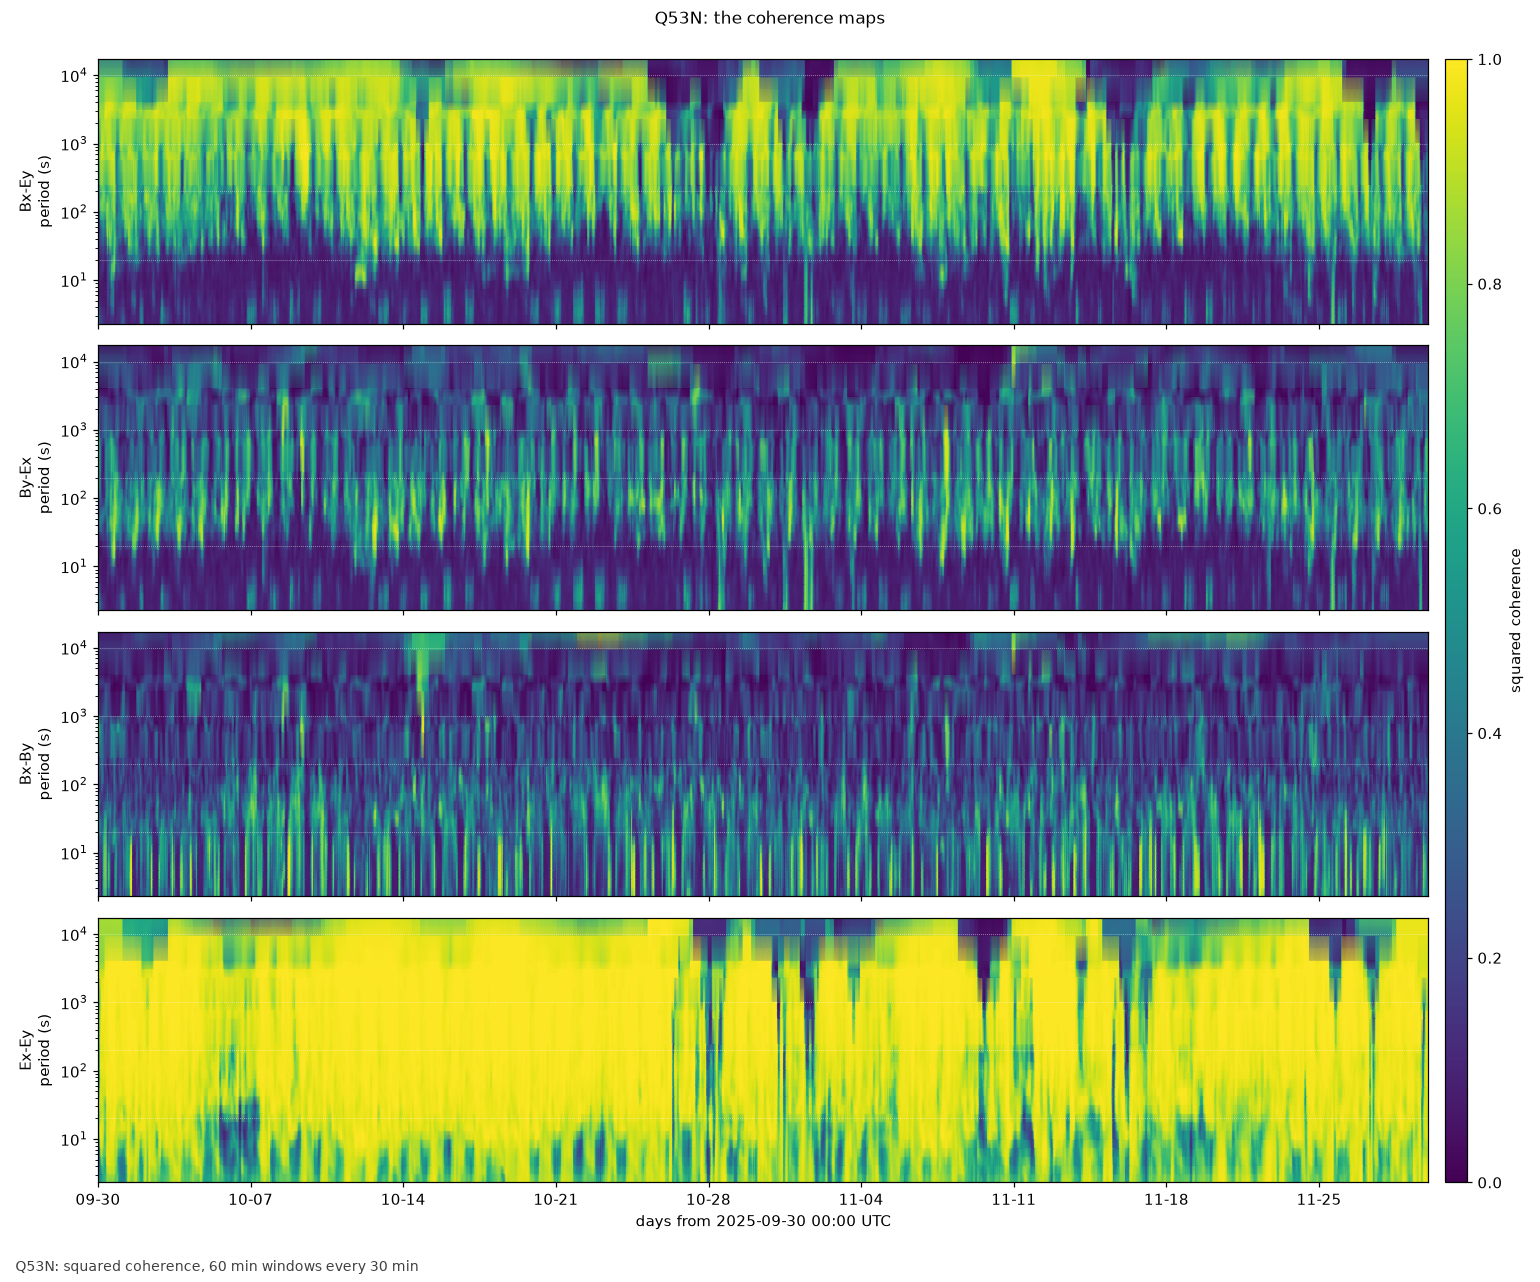

In [8]:
ladder = FSITE.levels_plan(1.0, WIN_MIN * 60, STEP_MIN * 60, pmax=PMAX)
print("the level ladder at 1 Hz with %d min windows every %d min, to %g s" % (WIN_MIN, STEP_MIN, PMAX))
print(ladder.to_string(index=False))
print()
print("%d levels; %d log bins per decade; the DC bin is dropped and a bin holding no FFT harmonic is dropped"
      % (len(ladder), FSITE.PER_DECADE))
print("guide lines at %s s; the maps carry a %g h running median along time and the band lines %g h"
      % (", ".join(str(g) for g in FSITE.GUIDE_S), FSITE.SMOOTH_H, FSITE.LINE_SMOOTH_H))
print()
map_png = WORK / SITE / "03_coherence_maps.png"
print("%s: %s" % (SITE, "03_coherence_maps.png is on disk" if map_png.exists() else "no coherence map on disk"))
show("03_coherence_maps.png")


## Spectra (figure 04)

One Welch spectrum per channel of `SITE` over the longest finite run of the record, 4,096-sample segments, the
DC bin dropped, on log-log axes with the 10-1000 s band shaded: that is where a 1 Hz fluxgate does its work
and where the transfer function will be read. The dotted line is the Nyquist period.

This section is a reading, not a check. A sound electric line falls 4.6-5.6 decades over 1 mHz to 3 Hz; a flat
spectrum, under 1 decade of fall over that span, is an open input, an electrode that is not connected to the
ground. On a 1 Hz cache 3 Hz is above the Nyquist frequency, so the fall is measured to 0.4 Hz instead and the
band used is printed with the numbers; the bound 1 decade still separates a line that falls from one that does
not.

Q53N        1.2 s

Q53N: decades of fall over 1 mHz - 0.4 Hz, and the power at 100 s
         decades_of_fall  power_at_100s
channel                                
Hx                  3.65       3.514167
Hy                  3.15       1.848489
Hz                  3.81       3.179996
Ex                  4.53     386.640775
Ey                  4.96     429.186220

electric lines of Q53N falling less than 1 decade (an open input, read and not scored): none


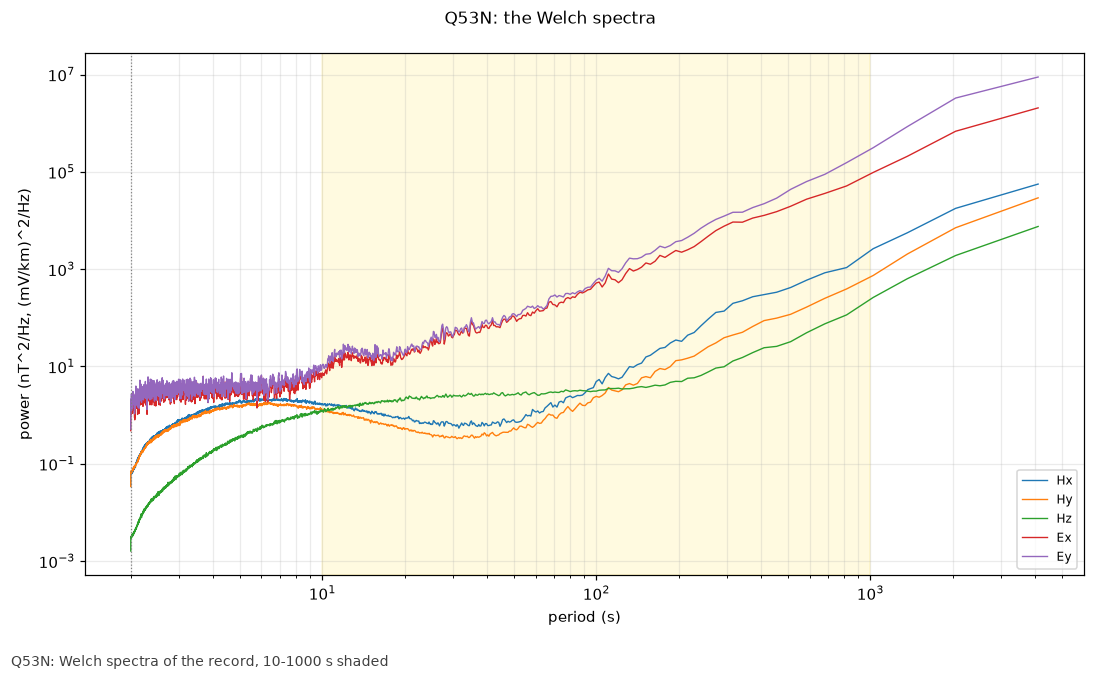

In [9]:
t = time.time()
t0, arrays, meta, row = load(SITE)
fig, fall = FSITE.spectra(arrays, site_dir(SITE) / "04_spectra.png", fs=1.0,
                          title="%s: Welch spectra of the record, 10-1000 s shaded" % SITE)
plt.close(fig)
WRITTEN.append(site_dir(SITE) / "04_spectra.png")
TIMING[SITE]["spectra_s"] = round(time.time() - t, 1)
del arrays

print("%-9s %5.1f s" % (SITE, TIMING[SITE]["spectra_s"]))
print()
print("%s: decades of fall over %s, and the power at 100 s" % (SITE, fall.fall_band.iloc[0]))
print(fall[["decades_of_fall", "power_at_100s"]].to_string())
print()
lines = fall.reindex([c for c in ("Ex", "Ey") if c in fall.index])
flat = lines[lines.decades_of_fall < 1.0]
print("electric lines of %s falling less than 1 decade (an open input, read and not scored): %s"
      % (SITE, "; ".join("%s %.2f" % (c, v) for c, v in zip(flat.index, flat.decades_of_fall)) or "none"))
show("04_spectra.png")


## Spectrograms (figure 05)

The power of each of `SITE`'s channels against time and period, in dB of absolute power density, with the
colour limits at that channel's own 2nd and 98th percentile, so a dead stretch is a dark band at every period
and a storm is bright across the whole picture. The table under it reads the base level of the same maps: the
median power in the 20-200 s band, and the fraction of windows more than 10 dB below it (an hour the channel
was quiet or dead) or above it (a burst).

The same maps are computed at every chosen site without their figure, because the survey table carries one
median power per channel per site; each site's table is written to `<work_root>/<site>/05_spectrograms.csv`.

A channel whose `windows 10 dB below` is a large fraction died part way through the record, and the days it
died are what the mask in workbook 04 will cut.

Q53N       32.2 s  Hx 0.1 dB Hy -2.5 dB Hz -4.2 dB Ex 18.4 dB Ey 18.3 dB

Q53N: the power at 20-200 s per channel, 60 min windows every 30 min
         median dB at 20-200 s  windows 10 dB below  windows 10 dB above  windows
channel                                                                          
Hx                         0.1                0.040                0.047     2928
Hy                        -2.5                0.060                0.058     2928
Hz                        -4.2                0.135                0.254     2928
Ex                        18.4                0.054                0.060     2928
Ey                        18.3                0.046                0.064     2928


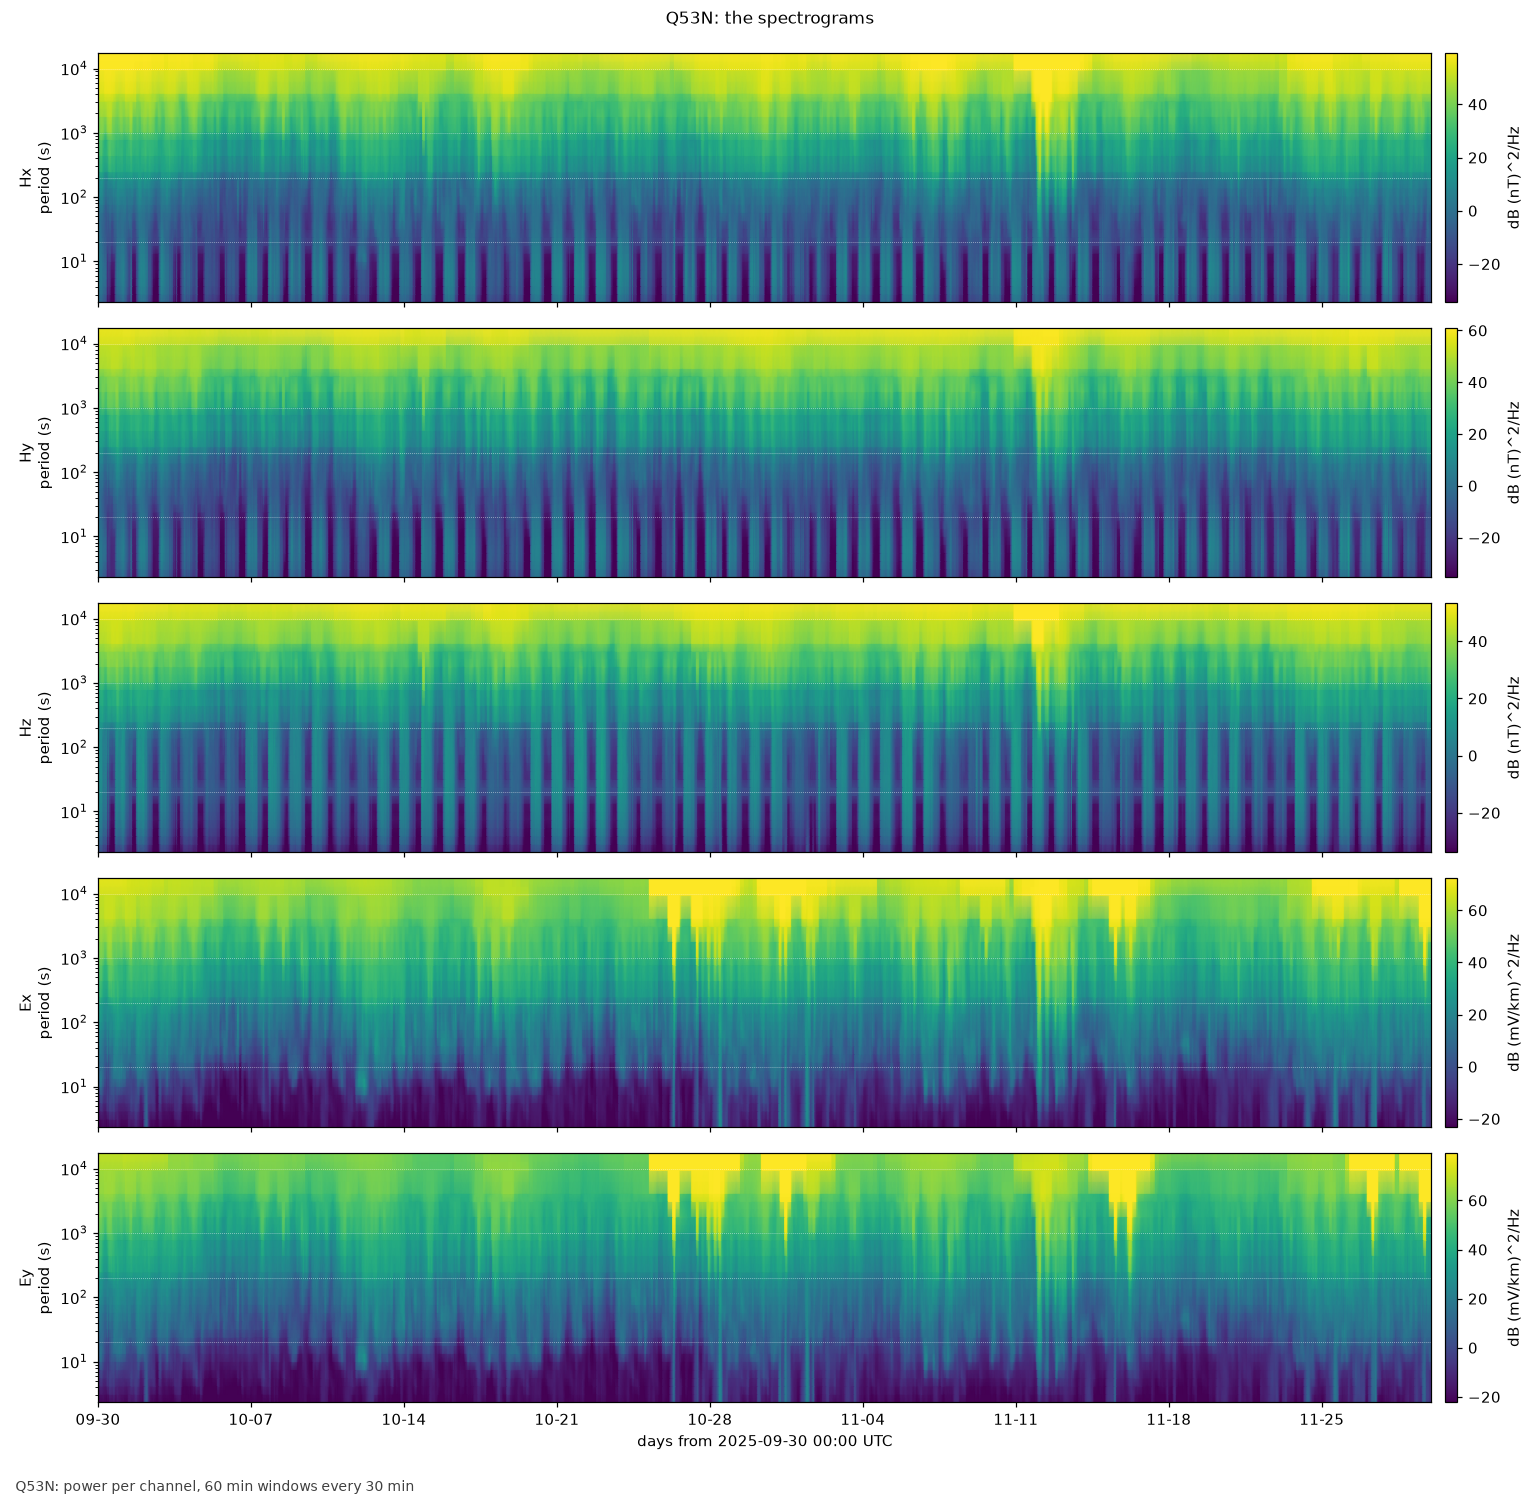

In [10]:
spec_rows = []
for s in CHOSEN:
    t = time.time()
    t0, arrays, meta, row = load(s)
    if s == SITE:                              # <- SITE: figure 05 is drawn, and returns the maps it drew
        fig, pmaps = FSITE.spectrograms(t0, arrays, site_dir(s) / "05_spectrograms.png", fs=1.0,
                                        win_s=WIN_MIN * 60, step_s=STEP_MIN * 60, pmax=PMAX,
                                        title="%s: power per channel, %d min windows every %d min"
                                              % (s, WIN_MIN, STEP_MIN))
        plt.close(fig)
        WRITTEN.append(site_dir(s) / "05_spectrograms.png")
    else:
        # the same level ladder the figure computes, without the figure: the survey table carries the median
        pmaps = {c: FSITE.power_levels(arrays[c], fs=1.0, win_s=WIN_MIN * 60, step_s=STEP_MIN * 60,
                                       pmax=PMAX) for c in FSITE.CHANNELS if c in arrays}
    tab = FSITE.spectrogram_table(pmaps)
    tab.to_csv(site_dir(s) / "05_spectrograms.csv")
    WRITTEN.append(site_dir(s) / "05_spectrograms.csv")
    for ch, r in tab.iterrows():
        spec_rows.append(dict(site=s, channel=ch, median_db=r["median dB at 20-200 s"],
                              frac_10db_below=r["windows 10 dB below"],
                              frac_10db_above=r["windows 10 dB above"], windows=r["windows"]))
    if s == SITE:
        site_power = tab
    TIMING[s]["spectrogram_s"] = round(time.time() - t, 1)
    del arrays, pmaps

spect = pd.DataFrame(spec_rows)
print("%-9s %5.1f s  %s" % (SITE, TIMING[SITE]["spectrogram_s"],
                            " ".join("%s %.1f dB" % (c, v) for c, v
                                     in zip(site_power.index, site_power["median dB at 20-200 s"]))))
print()
print("%s: the power at 20-200 s per channel, %d min windows every %d min" % (SITE, WIN_MIN, STEP_MIN))
print(site_power.to_string())
show("05_spectrograms.png")


## The survey table

One row per chosen site of what the five figures are read from: the total field against IGRF and the flags the
DC rule fired, the fraction of scored days each electric line was sound, common-mode, dead or weak, and the
median power at 20-200 s per channel. It is written to `<work_root>/survey/records_summary.csv`, and it is what
workbook 03 reads when it chooses which sites and which days to process.

`figures_on_disk` counts how many of the five figures are under `<work_root>/<site>/`. This run drew them for
`SITE` alone, so a count of five at any other site is from an earlier run of this workbook on that site. The
check is scored on what this run does: a row for every chosen site, the columns workbook 03 reads carrying a
number in each of them, and `SITE`'s five figures on disk.

**This check fails if the survey table has no row for a chosen site, if any row has a hole in the columns
workbook 03 reads, or if fewer than five of `SITE`'s figures 01 to 05 are on disk.**

In [11]:
FIGS = ["01_record.png", "02_coherence_bands.png", "03_coherence_maps.png", "04_spectra.png",
        "05_spectrograms.png"]
db = spect.pivot(index="site", columns="channel", values="median_db")
summary = (dc.set_index("site")[["days", "F_over_Figrf", "H_over_Higrf", "Bz_over_Z", "angle_deg", "flags"]]
           .join(esum.set_index("site")[["days_scored", "Ex_sound_frac", "Ex_weak_frac", "Ex_common_frac",
                                         "Ex_dead_frac", "Ey_sound_frac", "Ey_weak_frac", "Ey_common_frac",
                                         "Ey_dead_frac", "both_sound_frac"]])
           .join(db.rename(columns=lambda c: "db_20_200_%s" % c)))
summary["figures_on_disk"] = [sum((WORK / s / f).exists() for f in FIGS) for s in summary.index]
summary = summary.reset_index()
out_csv = WORK / "survey" / "records_summary.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_csv, index=False)
WRITTEN.append(out_csv)
print(summary.to_string(index=False))
print()
print("wrote %s (%d rows, %d columns)" % (out_csv, len(summary), len(summary.columns)))

# the columns workbook 03 reads: the DC ratios, the scored days and the fractions, the power per channel
NEEDED = (["days", "F_over_Figrf", "H_over_Higrf", "Bz_over_Z", "angle_deg", "days_scored",
           "Ex_sound_frac", "Ey_sound_frac", "both_sound_frac"]
          + ["db_20_200_%s" % c for c in FSITE.CHANNELS])
absent_cols = [c for c in NEEDED if c not in summary.columns]
absent_rows = [s for s in CHOSEN if s not in set(summary.site)]
holed = summary[summary[[c for c in NEEDED if c in summary.columns]].isna().any(axis=1)]
site_figs = [f for f in FIGS if (WORK / SITE / f).exists()]
print()
if not len(summary):
    print("VERDICT: UNJUDGED -- the chosen set is empty, so no site was scored")
elif absent_rows or absent_cols or len(holed) or len(site_figs) < len(FIGS):
    print("VERDICT: FAIL -- %d of %d chosen sites have no row (%s); %d of the %d columns workbook 03 reads "
          "are absent (%s); %d rows have a hole in them (%s); %d of the %d figures of %s are on disk (%s)"
          % (len(absent_rows), len(CHOSEN), ", ".join(absent_rows) or "none",
             len(absent_cols), len(NEEDED), ", ".join(absent_cols) or "none",
             len(holed), ", ".join(holed.site) or "none",
             len(site_figs), len(FIGS), SITE, ", ".join(site_figs) or "none"))
else:
    print("VERDICT: PASS -- all %d chosen sites carry a row of %d columns, the %d columns workbook 03 reads "
          "hold a number in every one of them, and all %d figures of %s are on disk"
          % (len(summary), len(summary.columns), len(NEEDED), len(FIGS), SITE))


  site  days  F_over_Figrf  H_over_Higrf  Bz_over_Z  angle_deg                                                             flags  days_scored  Ex_sound_frac  Ex_weak_frac  Ex_common_frac  Ex_dead_frac  Ey_sound_frac  Ey_weak_frac  Ey_common_frac  Ey_dead_frac  both_sound_frac  db_20_200_Ex  db_20_200_Ey  db_20_200_Hx  db_20_200_Hy  db_20_200_Hz  figures_on_disk
   Q49 60.64        0.9763        0.9583     0.9846      -3.78                                                                             60          0.150         0.717           0.083         0.050          0.017         0.850           0.083         0.050            0.000           9.5          24.8          29.2          -3.2         -13.0                5
   Q50 61.40        0.9956        0.9735     1.0059      -0.55                                                                             62          0.161         0.645           0.097         0.097          0.194         0.661           0.097         0.048            0

## What was written

In [12]:
rows = []
for p in sorted(set(WRITTEN)):
    p = Path(p)
    if p.exists():
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for r in tuple(RATES):
    for s in CHOSEN:
        for suffix in (".npz", ".json"):
            p = WORK / ("cache_%dhz" % r) / (s + suffix)
            if p.exists():
                rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print(files.to_string(index=False))
print()
print("%d files, %.1f MB" % (len(files), files.kb.sum() / 1024))
for r in tuple(RATES):
    d = WORK / ("cache_%dhz" % r)
    mb = sum(p.stat().st_size for p in d.glob("*.npz")) / 1024 ** 2 if d.exists() else 0.0
    print("cache_%dhz %.1f MB over %d files" % (r, mb, len(list(d.glob("*.npz"))) if d.exists() else 0))
print()
tm = pd.DataFrame(TIMING).T
tm["total_s"] = tm.sum(axis=1)
print("seconds per site; the spectra column is %s alone, the one site the figures are drawn for" % SITE)
print(tm.to_string())
print()
print("%d sites, %.1f minutes in all, %.1f s a site on average"
      % (len(tm), tm.total_s.sum() / 60.0, tm.total_s.mean()))


                                                                                 file        kb
    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\05_spectrograms.csv       0.2
                 E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\dc.csv       0.3
             E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\elines.csv       5.5
    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\05_spectrograms.csv       0.2
                 E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\dc.csv       0.3
             E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\elines.csv       5.5
    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q51\05_spectrograms.csv       0.2
                 E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q51\dc.csv       0.3
             E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q51\elines.csv       5.4
   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\